In [4]:
from ultralytics import YOLO
import numpy as np
import cv2
import torch
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch import nn
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import timm
import torch.optim as optim

/home/hice1/axu39/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# CONFIG
MAX_SIZE = 512
yolo_path = "../yolo/obb.pt"
test_image_id = 1075
training_data_dir = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/hrnet"
test_data_dir = "/storage/ice-shared/cs8903onl/hourglass-data/raw_data/test_data"
imgdir = "/storage/ice-shared/cs8903onl/hourglass-data/raw_data/miami_fall_24_jpgs"
tps_data_dir = "/storage/ice-shared/cs8903onl/hourglass-data/raw_data/tps_files"

TESTSET = ["1117", "1168", "1241", "1262", "1567", "1678", "1712", "1805", "1807", "1883"]
mlmorph_comp = "/home/hice1/axu39/lizard/Lizard_Toepads/stacked-hourglass/data/hrnet/mlmorphcomp"

def get_img(img_id):
    return cv2.imread(f"{imgdir}/{img_id}.jpg")

def get_tps_coords(img_id, img):
    tps_classes = ["finger", "toe"]
    ret = {}
    h, w = img.shape[:2]
    for c in tps_classes:
        fp = f"{tps_data_dir}/{img_id}_{c}.TPS"
        coordinates = []
        skip = 2
        with open(fp, "r") as f:
            for line in f:
                line = line.strip()
                if not line or "=" in line:
                    continue
                parts = line.split()
                if len(parts) == 2:
                    if skip > 0:
                        skip -= 1
                        continue
                    try:
                        x , y = map(float, parts)
                        
                        coordinates.append((x, h - 1 - y))
                        #print((x, y))
                    except ValueError:
                        continue
        ret[c] = coordinates
    return ret

def tps_to_heatmap(tps, crop, num_points=9, show=False, sigma=10):
    """
    Generate heatmaps for TPS points within a crop.
    Always returns `num_points` channels.
    """
    h, w = crop.shape[:2]
    heatmap = []
    yy, xx = np.mgrid[0:h, 0:w]

    # create heatmap for each point
    for i in range(num_points):
        hm = np.zeros((h, w), dtype=np.float32)
        if i < len(tps):
            x, y = tps[i]
            g = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * sigma**2))
            hm += g
        heatmap.append(hm)

        if show:
            copy = crop.copy()
            heatmap_uint8 = (hm * 255).astype(np.uint8)
            heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
            if heatmap_color.shape[:2] != copy.shape[:2]:
                heatmap_color = cv2.resize(heatmap_color, (copy.shape[1], copy.shape[0]))
            overlay = cv2.addWeighted(copy, 0.6, heatmap_color, 0.4, 0)
            cv2.imshow("Overlay", overlay)
            cv2.waitKey(0)
            cv2.destroyAllWindows()

    return np.stack(heatmap, axis=-1)  # shape (H, W, num_points)

DEBUG_CROP_TARGET = 10
# Model only detects "bottom" finger (0) and toe (1). Annotated side: original image.
# Unannotated side: run the same classes after cv2.flip(img, 0) and save those crops as test data.
TRAIN_CLASSES = [0, 1]
CLASSMAP = {0: "finger", 1: "toe"}

def reversible_rescale(img, keypoints=None, max_size=512):
    h, w = img.shape[:2]
    scale = min(max_size / h, max_size / w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (new_w, new_h))
    pad_x = (max_size - new_w) // 2
    pad_y = (max_size - new_h) // 2
    padded = np.zeros((max_size, max_size, 3), dtype=np.uint8)
    padded[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized
    padded = padded.astype(np.float32) / 255.0
    padded = (padded - np.array([0.485,0.456,0.406])) / np.array([0.229,0.224,0.225])
    if keypoints is None:
        return padded, scale, pad_x, pad_y

    kps = np.array(keypoints, dtype=np.float32).copy()
    kps[:, 0] = kps[:, 0] * scale + pad_x
    kps[:, 1] = kps[:, 1] * scale + pad_y

    return padded, kps, scale, pad_x, pad_y

def process_special_test(imgid):
    model = YOLO(yolo_path)

    img = get_img(imgid)
    if img is None:
        print(f"[{imgid}] Missing image, skipping")
        return
    tps = get_tps_coords(imgid, img, tps_data_dir)
    # 1) Training data: original image, YOLO classes 0 and 1
    results_train = model(img, verbose=False)
    crops, local_tps_coords, stats, Ms = crop_toe_boxes_obb(
        results_train[0],
        img,
        tps,
        imgid,
        debug_state=None,
        target_classes=TRAIN_CLASSES,
        expected_points=9,
    )

    for i, crop in enumerate(crops):
        if i > 1:
            break
        
        img_aug, kps_aug, scale, pad_x, pad_y = reversible_rescale(crop, local_tps_coords[i])

        if kps_aug.shape[0] != 9:
            print(f"FAILED TO GENERATE MLMORPH TRN SAMPLE {imgid}")
            continue
        h_crop, w_crop = crop.shape[:2]
        pt_path = f"{mlmorph_comp}/{imgid}_{i}_b.pt"
        torch.save(
            {
                "image": torch.from_numpy(img_aug).permute(2, 0, 1).to(torch.float32),
                "tps": torch.from_numpy(kps_aug).to(torch.float32),
                "scale": torch.tensor(scale, dtype=torch.float32),
                "pad": torch.tensor([pad_x, pad_y], dtype=torch.float32),
                "M": torch.from_numpy(Ms[i]).to(torch.float32),
            },
            pt_path,
        )

    # 2) Test data: vertical flip, rerun YOLO; save class 0/1 crops unchanged to same test paths
    img_flip = cv2.flip(img, 0)
    results_test = model(img_flip, verbose=False)
    Path(test_data_dir).mkdir(parents=True, exist_ok=True)
    saved = 0
    obb_corners = results_test[0].obb.xyxyxyxy.cpu().numpy()  # (N,4,2)
    cls_ids = results_test[0].obb.cls.cpu().numpy()
    for j, (corners, cls_id) in enumerate(zip(obb_corners, cls_ids)):
        cls_id = int(cls_id)
        if cls_id not in TRAIN_CLASSES:
            continue
        crop, M = crop_obb_from_corners(img_flip, corners)
        
        img_aug, scale, pad_x, pad_y = reversible_rescale(crop)
        
        side_name = CLASSMAP[cls_id]
        t_path = f"{mlmorph_comp}/{imgid}_{j}_t.pt"
        torch.save(
            {
                "image": torch.from_numpy(img_aug).permute(2, 0, 1).to(torch.float32),
                "scale": torch.tensor(scale, dtype=torch.float32),
                "pad": torch.tensor([pad_x, pad_y], dtype=torch.float32),
                "M": torch.from_numpy(M).to(torch.float32),
            },
            t_path,
        )


def process_images():
    dir_path = Path(imgdir)
    Path(f"{training_data_dir}/crops").mkdir(parents=True, exist_ok=True)
    debug_state = {"saved": 0, "displayed": False}

    count = 0
    for file in dir_path.iterdir():
        print(f"Processing file {count}", end="\r", flush=True)

        if ".jpg" in file.name:
            imgid = file.name.replace(".jpg", "")
            if imgid in TESTSET:
                process_special_test(imgid)
                continue
                
            if int(imgid) > 1000:
                process_image(imgid, debug_state)
        count += 1

    print(f"\nDebug overlays saved: {debug_state['saved']} at {training_data_dir}/crops")


def generate_overlay(crop, heatmaps):
    # Step 1: Combine heatmaps across channels (max intensity)
    combined = np.max(heatmaps, axis=2)  # shape (H,W), still float32 [0,1]

    # Step 2: Convert to uint8 0-255
    combined_uint8 = (np.clip(combined, 0, 1) * 255).astype(np.uint8)

    # Step 3: Apply color map
    heatmap_color = cv2.applyColorMap(combined_uint8, cv2.COLORMAP_JET)  # (H,W,3) uint8

    # Step 4: Resize if needed (match crop)
    if heatmap_color.shape[:2] != crop.shape[:2]:
        heatmap_color = cv2.resize(heatmap_color, (crop.shape[1], crop.shape[0]), interpolation=cv2.INTER_LINEAR)

    # Step 5: Blend overlay
    overlay = cv2.addWeighted(crop, 0.6, heatmap_color, 0.4, 0)

    return overlay


def order_box_points(pts):
    """Return points ordered as top-left, top-right, bottom-right, bottom-left."""
    pts = np.array(pts, dtype=np.float32)
    y_sorted = pts[np.argsort(pts[:, 1])]
    top = y_sorted[:2]
    bottom = y_sorted[2:]

    top = top[np.argsort(top[:, 0])]
    bottom = bottom[np.argsort(bottom[:, 0])]

    tl, tr = top[0], top[1]
    bl, br = bottom[0], bottom[1]
    return np.array([tl, tr, br, bl], dtype=np.float32)


def crop_obb_from_corners(image, corners):
    """Crop from YOLO OBB polygon corners and return crop + homography."""
    box = order_box_points(corners)
    width = int(max(1, round(np.linalg.norm(box[1] - box[0]))))
    height = int(max(1, round(np.linalg.norm(box[2] - box[1]))))

    dst = np.array(
        [[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]],
        dtype=np.float32,
    )
    M = cv2.getPerspectiveTransform(box, dst)
    crop = cv2.warpPerspective(image, M, (width, height))
    return crop, M


def transform_keypoints(kps, M):
    """Transform global TPS coordinates into local crop coordinates."""
    kps = np.array(kps, dtype=np.float32).reshape(-1, 1, 2)
    local_kps = cv2.perspectiveTransform(kps, M)
    return local_kps.reshape(-1, 2)


# -------------------------------
# TPS loading (with flipped Y)
# -------------------------------

def get_tps_coords(img_id, img, tps_dir):
    """Load TPS coords and flip Y to match image coordinates"""
    tps_classes = ["finger", "toe"]
    h, w = img.shape[:2]
    ret = {}

    for c in tps_classes:
        fp = f"{tps_dir}/{img_id}_{c}.TPS"
        coords = []
        skip = 2
        with open(fp, "r") as f:
            for line in f:
                line = line.strip()
                if not line or "=" in line:
                    continue
                parts = line.split()
                if len(parts) == 2:
                    if skip > 0:
                        skip -= 1
                        continue
                    try:
                        x, y = map(float, parts)
                        # Flip Y from TPS (origin bottom-left) to image (top-left)
                        coords.append((x, h - 1 - y))
                    except ValueError:
                        continue
        ret[c] = coords
    return ret


# -------------------------------
# Crop YOLO OBB boxes + transform TPS
# -------------------------------

def save_test_crops_obb(result, image, output_name, test_classes=None):
    """Save OBB warped crops to test_data_dir only (no resize/pad/normalize)."""
    if test_classes is None:
        test_classes = TRAIN_CLASSES
    if result.obb is None:
        return 0

    Path(test_data_dir).mkdir(parents=True, exist_ok=True)
    saved = 0
    obb_corners = result.obb.xyxyxyxy.cpu().numpy()  # (N,4,2)
    cls_ids = result.obb.cls.cpu().numpy()

    for corners, cls_id in zip(obb_corners, cls_ids):
        cls_id = int(cls_id)
        if cls_id not in test_classes:
            continue

        crop, _ = crop_obb_from_corners(image, corners)
        side_name = CLASSMAP[cls_id]
        outpath = f"{test_data_dir}/{output_name}_{side_name}.jpg"
        cv2.imwrite(outpath, crop)
        saved += 1

    return saved


def crop_toe_boxes_obb(result, image, g_coords, imgid, debug_state=None, target_classes=TRAIN_CLASSES, expected_points=9):
    """Crop OBB boxes and transform global TPS points to local crop coordinates."""
    crops, tps_local = [], []
    stats = {
        "total_target_boxes": 0,
        "kept": 0,
        "dropped_missing_tps": 0,
        "dropped_bad_count": 0,
        "dropped_out_of_bounds": 0,
    }

    if result.obb is None:
        return crops, tps_local, stats

    obb_corners = result.obb.xyxyxyxy.cpu().numpy()  # (N,4,2)
    cls_ids = result.obb.cls.cpu().numpy()
    Ms = []
    for det_idx, (corners, cls_id) in enumerate(zip(obb_corners, cls_ids)):
        cls_id = int(cls_id)
        if cls_id not in target_classes:
            continue

        stats["total_target_boxes"] += 1
        class_name = CLASSMAP[cls_id]
        global_kps = g_coords.get(class_name, [])
        if len(global_kps) == 0:
            stats["dropped_missing_tps"] += 1
            continue
        if len(global_kps) != expected_points:
            stats["dropped_bad_count"] += 1
            continue

        crop, M = crop_obb_from_corners(image, corners)
        local_kps = transform_keypoints(global_kps, M)
        Ms.append(M)
        h_crop, w_crop = crop.shape[:2]
        in_bounds = (local_kps[:, 0] >= 0) & (local_kps[:, 0] < w_crop) & \
                    (local_kps[:, 1] >= 0) & (local_kps[:, 1] < h_crop)

        is_kept = bool(np.all(in_bounds))
        if not is_kept:
            stats["dropped_out_of_bounds"] += 1
        else:
            crops.append(crop)
            tps_local.append(local_kps.astype(np.float32))
            stats["kept"] += 1

        # Save first DEBUG_CROP_TARGET overlays regardless of keep/drop.
        if debug_state is not None and debug_state["saved"] < DEBUG_CROP_TARGET:
            vis = crop.copy()
            for kp_idx, (x, y) in enumerate(local_kps):
                color = (0, 255, 0) if in_bounds[kp_idx] else (0, 0, 255)
                cv2.circle(vis, (int(round(x)), int(round(y))), 4, color, -1)
                cv2.putText(
                    vis,
                    str(kp_idx),
                    (int(round(x)) + 5, int(round(y)) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    color,
                    1,
                    cv2.LINE_AA,
                )
            status = "kept" if is_kept else "drop"
            debug_path = f"{training_data_dir}/crops/debug_{debug_state['saved']:02d}_{imgid}_{det_idx}_{status}.jpg"
            cv2.imwrite(debug_path, vis)

            if not debug_state.get("displayed", False):
                plt.figure(figsize=(6, 6))
                plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
                plt.title(f"Debug OBB overlay: {status} ({imgid})")
                plt.axis("off")
                plt.show()
                debug_state["displayed"] = True

            debug_state["saved"] += 1

    return crops, tps_local, stats, Ms


def process_image(imgid, debug_state=None):
    model = YOLO(yolo_path)

    img = get_img(imgid)
    if img is None:
        print(f"[{imgid}] Missing image, skipping")
        return

    tps = get_tps_coords(imgid, img, tps_data_dir)

    # 1) Training data: original image, YOLO classes 0 and 1
    results_train = model(img, verbose=False)
    crops, local_tps_coords, stats, _ = crop_toe_boxes_obb(
        results_train[0],
        img,
        tps,
        imgid,
        debug_state=debug_state,
        target_classes=TRAIN_CLASSES,
        expected_points=9,
    )

    for i, crop in enumerate(crops):
        if i > 1:
            break

        base_transform = A.Compose(
            [
                A.LongestMaxSize(max_size=MAX_SIZE),
                A.PadIfNeeded(
                    MAX_SIZE,
                    MAX_SIZE,
                    border_mode=cv2.BORDER_CONSTANT,
                ),
            ],
            keypoint_params=A.KeypointParams(
                format="xy",
                remove_invisible=False,
            ),
        )

        aug = base_transform(
            image=crop,
            keypoints=local_tps_coords[i],
        )

        img_aug = aug["image"]
        kps_aug = np.array(aug["keypoints"], dtype=np.float32)

        if kps_aug.shape[0] != 9:
            print()
            print(f"[{imgid}] Keypoint mismatch after aug: {kps_aug.shape}")
            continue
        h_crop, w_crop = crop.shape[:2]
        pt_path = f"{training_data_dir}/heatmaps/{imgid}_{i}_b.pt"
        torch.save(
            {
                "image": torch.from_numpy(img_aug).permute(2, 0, 1).to(torch.uint8),
                "tps": torch.from_numpy(kps_aug).to(torch.float32),
                "orig_size": torch.tensor([h_crop, w_crop], dtype=torch.float32),
            },
            pt_path,
        )

    # 2) Test data: vertical flip, rerun YOLO; save class 0/1 crops unchanged to same test paths
    img_flip = cv2.flip(img, 0)
    results_test = model(img_flip, verbose=False)
    test_saved = save_test_crops_obb(
        results_test[0],
        img_flip,
        output_name=imgid,
        test_classes=TRAIN_CLASSES,
    )

    if stats["total_target_boxes"] > 0 or test_saved > 0:
        print(
            f"[{imgid}] train_kept={stats['kept']}/{stats['total_target_boxes']} "
            f"drop_missing={stats['dropped_missing_tps']} "
            f"drop_bad_count={stats['dropped_bad_count']} "
            f"drop_oob={stats['dropped_out_of_bounds']} "
            f"test_saved={test_saved}"
        )

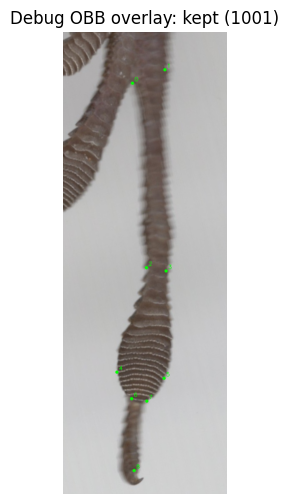

[1001] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=3
[1002] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1003] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1004] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1005] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1006] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1007] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1008] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=3
[1009] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1010] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1011] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1012] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0 test_saved=2
[1013] train_kept=2/2 drop_missing=0 drop_bad_count=0 drop_oob=0

ValueError: invalid literal for int() with base 10: '2.99'

In [11]:
process_images()